# MJO 2: Compute the Daily Anomalies

via `daily_anom.ncl`

In [1]:
import os
import xarray as xr
from geocat.comp import climate_anomaly

In [2]:
CASENAME = "QBOi.EXP1.AMIP.001"
startdate = '19790101'
enddate = '19811231'

# /glade/u/home/bundy/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/diagnostics/MJO_suite/MJO_driver.py
#DATADIR = "/glade/u/home/bundy/diag/mdtf/inputdata/model/QBOi.EXP1.AMIP.001/"
WORK_DIR = os.getcwd()
DATADIR = "/data/"

U200_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.U200.day.nc"
V200_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.V200.day.nc"
U850_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.U850.day.nc"
V850_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.V850.day.nc"
RLUT_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.FLUT.day.nc"
PR_FILE = WORK_DIR + DATADIR + "QBOi.EXP1.AMIP.001.PRECT.day.nc"

lev_coord = "lev"
lat_coord = "lat"
lon_coord = "lon"
time_coord = "time"
pr_var = "PRECT"
rlut_var = "FLUT"

u200_var = "U200"
v200_var = "V200"

wk_dir = WORK_DIR + "/model/"

In [3]:
yr1 = int(startdate)
yr2 = int(enddate)

# encode datetime with milliseconds
start_date = (yr1 * 10000)+201       # 19790101 -> 197901010201
end_date = ((yr2 + 1) * 10000) + 101 # 19811231 -> 198112320101
print(f"Date from {start_date} to {end_date}")

delete_existing = True # True = overwrite, False = don't overwrite
if delete_existing: 
    anom_files = [file for file in os.listdir(wk_dir) if ".anom" in file]
    if len(anom_files) != 0:
        print("\nWARNING: daily_anom.ncl deleting existing anom files\n")
    var_files = [file for file in os.listdir(wk_dir) if ".nc" in file]
    print(f"({wk_dir}) contains 'anom': {anom_files}")   
    #print(f"({wk_dir}) contains '.nc' : {var_files}")   

Date from 197901010201 to 198112320101
(/home/cs/Github/geocat-research/mjo/model/) contains 'anom': []


In [4]:
file_netcdf = xr.open_dataset(wk_dir + "QBOi.EXP1.AMIP.001.pr.day.nc")
file_netcdf

<xarray.Dataset> Size: 2MB
Dimensions:                        (gw: 83, time: 2555)
Coordinates:
  * gw                             (gw) int64 664B 0 1 2 3 4 ... 78 79 80 81 82
  * time                           (time) object 20kB 1975-01-01 00:00:00 ......
Data variables:
    __xarray_dataarray_variable__  (gw, time) object 2MB ...
Attributes:
    __xarray_dataarray_name__:  time

In [5]:
# convert mixed Julian/Gregorian date to a UT-referenced date
# via NCL: cd_calendar --> cd_calendar(time, -2)
# Returns values in YYYYMMDD as an integer
#def cd_calendar(date):
#    from datetime import datetime, timedelta

    # start date as datetime
#    start_datetime = datetime(1975, 1, 1, 0, 0, 0)
    
    # collect all datetimes
#    time_all = []
#    for day_since_start in days_since_date:
#        next_day = (start_datetime + timedelta(days=day_since_start))
#        day_YYYYMMDD = next_day.strftime("%Y%m%d")
#        time_all.append(int(day_YYYYMMDD))
#    
#    print(f"Start date = {time_all[0]}, End date = {time_all[-1]}")
#    return time_all

In [6]:
var_names = ["pr", "rlut", "u200", "u850", "v200", "v850"]

for i in range(len(var_names)):
    var_name = var_names[i]
    print(f"daily_anom starting variable {var_name}")
    file_in = wk_dir + CASENAME + "." + var_name + ".day.nc"
    print(f"\tFile in:  {file_in}")
    file_out = wk_dir + CASENAME + "." + var_name + ".day.anom.nc"
    print(f"\tFile out: {file_out}")

    if os.path.exists(file_out) and not delete_existing:
        print(f"{file_out} already exists. To force recalculation, set daily_anom.ncl delete_existing = True\n")
    else:
        if os.path.exists(file_out) and delete_existing:
            print(f"{file_out} already exists. Overwriting since delete_existing = True\n")
            os.remove(file_out)

        if os.path.exists(file_in):
            print(f"reading {file_in}\n")
            input_file = xr.open_dataset(file_in)
            #print(input_file)
            time = input_file[time_coord]
            gw = input_file["gw"]
            break
            #date = cd_calendar(time)''' ## YYYYMMDD

daily_anom starting variable pr
	File in:  /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.nc
	File out: /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.anom.nc
reading /home/cs/Github/geocat-research/mjo/model/QBOi.EXP1.AMIP.001.pr.day.nc



In [7]:
input_files = [file for file in os.listdir(WORK_DIR + DATADIR) if ".nc" in file]
input_files

['QBOi.EXP1.AMIP.001.V850.day.nc',
 'QBOi.EXP1.AMIP.001.U850.day.nc',
 'QBOi.EXP1.AMIP.001.U200.day.nc',
 'QBOi.EXP1.AMIP.001.V200.day.nc',
 'QBOi.EXP1.AMIP.001.FLUT.day.nc',
 'QBOi.EXP1.AMIP.001.PRECT.day.nc']

In [8]:
xr.open_dataset(U200_FILE)

<xarray.Dataset> Size: 565MB
Dimensions:    (time: 2555, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    U200       (time, lat, lon) float32 565MB ...

In [9]:
xr.open_dataset(V200_FILE)

<xarray.Dataset> Size: 571MB
Dimensions:    (time: 2580, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 21kB 1975-01-01 00:00:00 ... 1982-01-25 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    V200       (time, lat, lon) float32 571MB ...
Attributes: (12/17)
    interp_type:               bilinear
    interp_outputgridtype:     equally spaced with poles
    np:                        4
    ne:                        30
    Conventions:               CF-1.0
    source:                    CAM
    ...                        ...
    revision_Id:               $Id$
    initial_file:              /glade/p/work/jrichter/60Lcam5301_B6ORO1F85/ca...
    topography_file:           /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/...
    history:                   Tue Dec 31 16:01:05 2024: ncatted -a calendar,...
    NCO:                       netCDF Operators version 5.1.9 (Homepage = htt...
    nco_openmp_thread_number:  1

In [10]:
xr.open_dataset(U850_FILE)

<xarray.Dataset> Size: 565MB
Dimensions:    (time: 2555, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    U850       (time, lat, lon) float32 565MB ...

In [11]:
xr.open_dataset(V850_FILE)

<xarray.Dataset> Size: 571MB
Dimensions:  (time: 2580, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 21kB 1975-01-01 00:00:00 ... 1982-01-25 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) int32 10kB ...
    V850     (time, lat, lon) float32 571MB ...
Attributes:
    history:                    Tue Dec 31 16:05:07 2024: ncatted -a calendar...
    history_of_appended_files:  Thu Nov 15 11:43:58 2018: Appended file QBOi....
    NCO:                        netCDF Operators version 5.1.9 (Homepage = ht...

In [12]:
xr.open_dataset(RLUT_FILE)

<xarray.Dataset> Size: 565MB
Dimensions:    (time: 2555, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    FLUT       (time, lat, lon) float32 565MB ...
Attributes:
    history:  Thu Mar  6 13:31:31 2025: ncatted -a cell_methods,FLUT,m,c,time...
    NCO:      netCDF Operators version 5.3.1 (Homepage = http://nco.sf.net, C...

In [13]:
xr.open_dataset(PR_FILE)

<xarray.Dataset> Size: 565MB
Dimensions:    (time: 2555, nbnd: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
Dimensions without coordinates: nbnd
Data variables:
    date       (time) int32 10kB ...
    time_bnds  (time, nbnd) object 41kB ...
    PRECT      (time, lat, lon) float32 565MB ...

### Calculate climate_anomaly

In [14]:
# set up anomaly directory

anom_dir = WORK_DIR + DATADIR + "anomaly/"
if not os.path.exists(anom_dir): os.makedirs(anom_dir)

In [15]:
delete_existing = True

for input_nc in input_files:
    file_nc = input_nc.split(".")[4]
    var_name = file_nc.lower()
    file_in = WORK_DIR + DATADIR + input_nc
    file_out = anom_dir + CASENAME + "." + var_name + ".day.anom.nc"
    print(f"\nCalculating anomaly for {file_in}")

    # calculate daily anomaly
    if delete_existing:
        input_xarray = xr.open_dataset(file_in)
              
        climate_anom_xarray = climate_anomaly(input_xarray, freq="day")

        if "time_bnds" in climate_anom_xarray.data_vars:
            # drop time_bnds in output file to fix keyerror for "time_bnds" in output file
            climate_anom_xarray = climate_anom_xarray.drop_vars("time_bnds")

        print(climate_anom_xarray)
        climate_anom_xarray.to_netcdf(file_out)
    else:
        print("Keeping existing anom files")


Calculating anomaly for /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001.V850.day.nc
<xarray.Dataset> Size: 571MB
Dimensions:  (time: 2580, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 21kB 1975-01-01 00:00:00 ... 1982-01-25 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 21kB -3.5e+04 -3.5e+04 -3.5e+04 ... 3.5e+04 3.5e+04
    V850     (time, lat, lon) float32 571MB nan nan nan ... 3.219 3.219 3.219
Attributes:
    history:                    Tue Dec 31 16:05:07 2024: ncatted -a calendar...
    history_of_appended_files:  Thu Nov 15 11:43:58 2018: Appended file QBOi....
    NCO:                        netCDF Operators version 5.1.9 (Homepage = ht...

Calculating anomaly for /home/cs/Github/geocat-research/mjo/data/QBOi.EXP1.AMIP.001.U850.day.nc
<xarray.Dataset> Size: 565MB
Dimensions:  (time: 2555

In [16]:
# "compute_daily_anom() - L61
# function in calc_utils.ncl - L371

#import xarray as xr
#from geocat.comp import climate_anomaly
#from matplotlib import pyplot as plt
#import datetime

#def compute_daily_anom(data_as_nc, is_plot=False):
    # compute the daily anomaly
    # See; calcDayAnom in geocat-applications
#    ds = xr.open_dataset(data_as_nc)
    # calculates climate anomalies by subtracting the long-term mean of each 'freq' period (e.g. 'day')
    #calcDayAnomTLL = climate_anomaly(dset=ds.aice_d,
      #                               freq="day",
     #                               tim_dim=None) # anomalies from daily climatology

    # optional plotting
    #if is_plot:
    #    calcDayAnomTLL[0, ;, ;].assign_attrs(long_name="CAM2 Anomaly").plot()
    #return calcDayAnomTLL

#### Plot Anomaly

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [18]:
def plot_anomaly(ds, vars_type):
    var_average = ds.sel(time="1980")[var_type.upper()].mean(dim="time")
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    var_average.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': 'Average Value'})

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    plt.title(f"Average Anomaly {var_type.upper()} in 1980")

    plt.show()

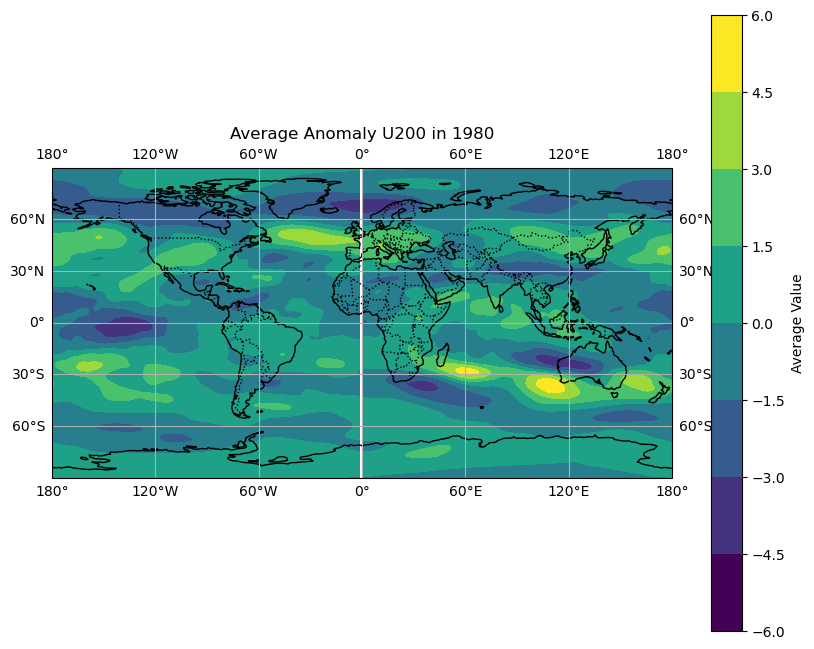

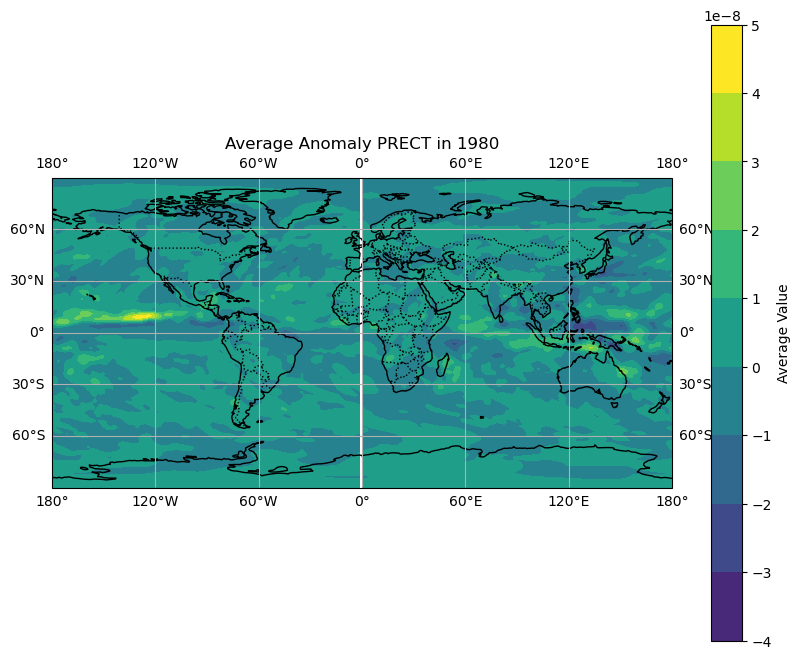

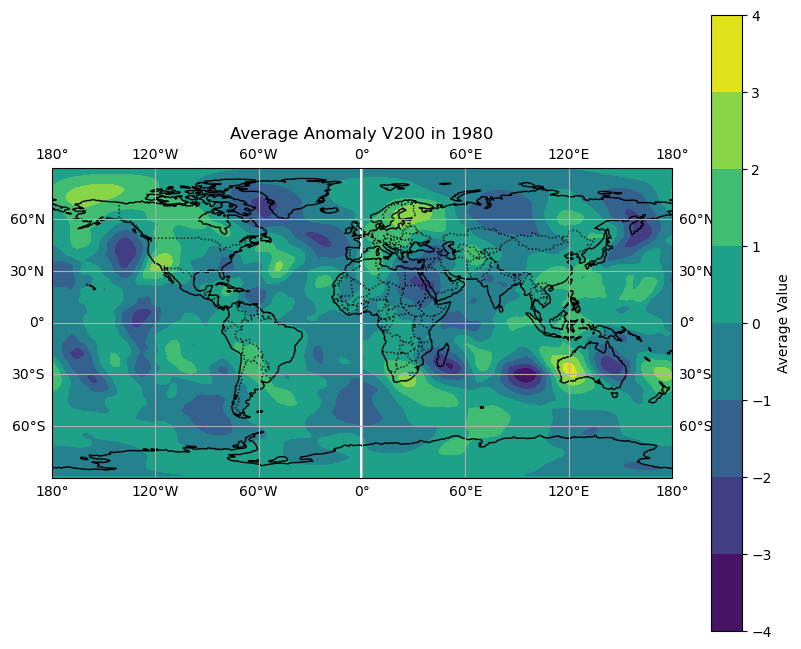

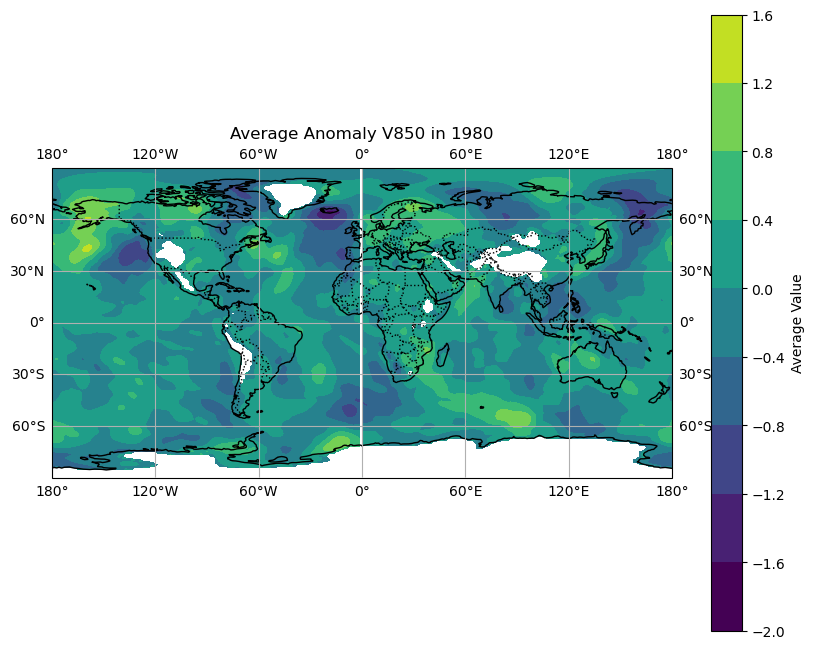

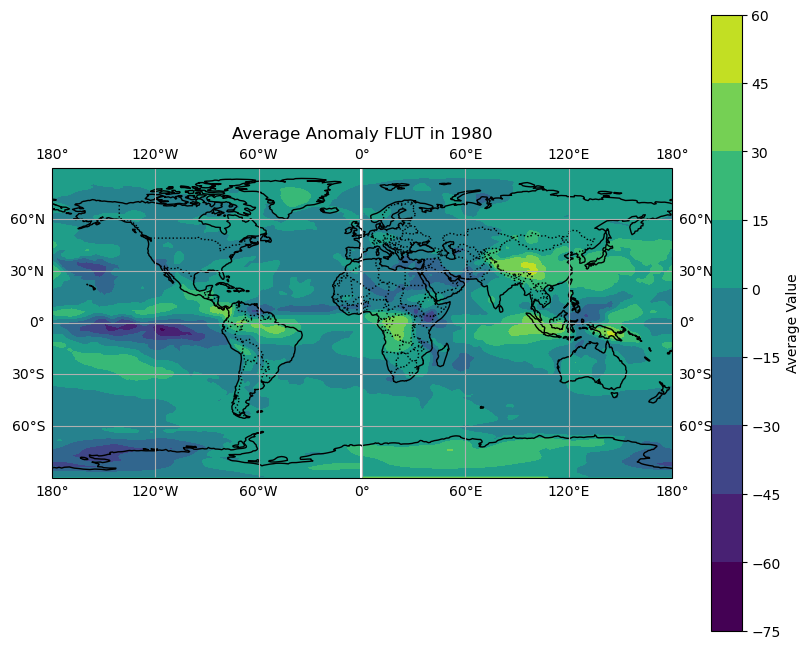

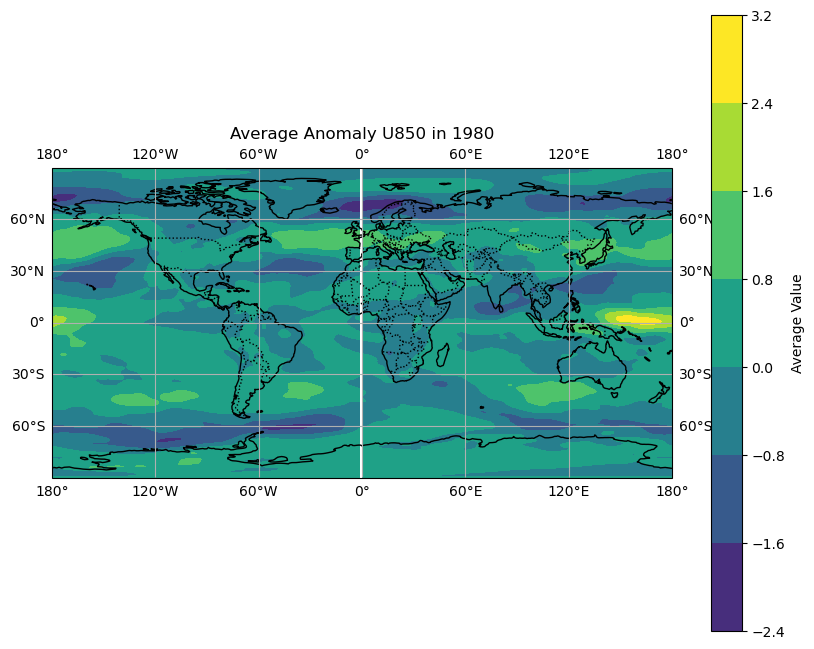

In [19]:
anom_files = [file for file in os.listdir(anom_dir) if "anom" in file]
for anom in anom_files:
    data_xarray = xr.open_dataset(anom_dir + anom)
    var_type = anom.split(".")[4]
    plot_anomaly(data_xarray, var_type)